# Chapter 8 (extra) — Staircase Voltammetry

Staircase voltammetry is the digital implementation of cyclic voltammetry used
by most commercial potentiostats. It can be viewed in two complementary ways,
both developed by Honeychurch in SERM:

1. **As a series of potential steps** — the staircase waveform drives the same
   implicit finite-difference engine as chronoamperometry (Chapter 8 main
   notebook), so a staircase voltammogram is just a step simulation with the
   right excitation. The current sampled once per step gives the voltammogram.
2. **As a sawtooth ripple superimposed on a linear ramp** — which makes the
   Fourier methods of Chapter 7 applicable: the staircase ripple shows up as a
   harmonic comb at multiples of the step frequency, and a moving-average filter
   of width equal to the step period isolates the dc (analogue-CV-like) envelope.

This notebook covers all three analyses Honeychurch presents:

- **sampling-point ($\beta$) analysis** — where in the step to read the current
  so that the staircase peak matches analogue linear-sweep voltammetry;
- the **dc moving-average** separation of the diffusion envelope;
- the **frequency-domain** decomposition of the staircase ripple.

We reuse the validated quasi-reversible step solver in
`serm.ch08_step_pulse` and the shared `serm.filters` moving average; no data from
the book is used — every curve is regenerated and validated against an
independent limit.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join('..','..')))
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from serm.ch08_step_pulse import staircase_eta, staircase_simulate, sample_at_beta
from serm.filters import moving_average
from serm.kinetics import f_thermal

f = f_thermal(298.15)        # nF/RT, 1/V
print(f"f = nF/RT = {f:.4f} 1/V")

f = nF/RT = 38.9217 1/V


## The staircase waveform

The staircase holds a flat potential for `tN` time levels, then steps down by
$\Delta E_s$. In dimensionless form $\eta = f(E-E^\circ)$ the waveform is
`upper - dEs*((k - k%tN)/tN)` — a backward staircase that, as $\Delta E_s\to0$,
approaches a linear ramp.

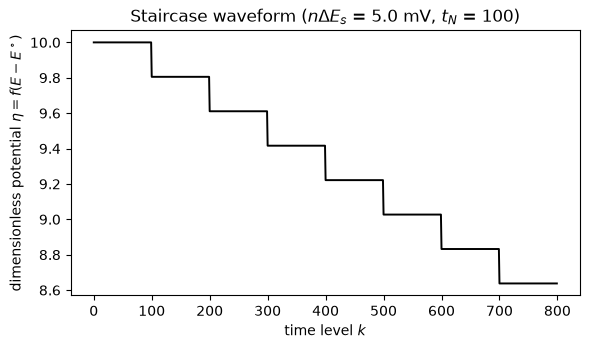

In [2]:
upper = 10.0
amp_mV = 5.0                          # step amplitude in mV
dEs = f * amp_mV * 1e-3               # dimensionless step height
tN = 100                             # time levels per step
n_demo = 8 * tN

eta_demo = staircase_eta(n_demo, upper, dEs, tN)

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(np.arange(n_demo), eta_demo, lw=1.4, color='k')
ax.set_xlabel("time level $k$")
ax.set_ylabel(r"dimensionless potential $\eta=f(E-E^\circ)$")
ax.set_title(f"Staircase waveform ($n\\Delta E_s$ = {amp_mV} mV, $t_N$ = {tN})")
fig.tight_layout(); plt.show()

## Simulating the staircase voltammogram

Driving the quasi-reversible step solver with the staircase $\xi=e^\eta$ gives a
dimensionless current at *every* time level. The full per-level trace is the
"raw" staircase current; the voltammogram is obtained by sampling one current
per step (next section).

n = 12000 time levels, 120 steps of 100 levels each


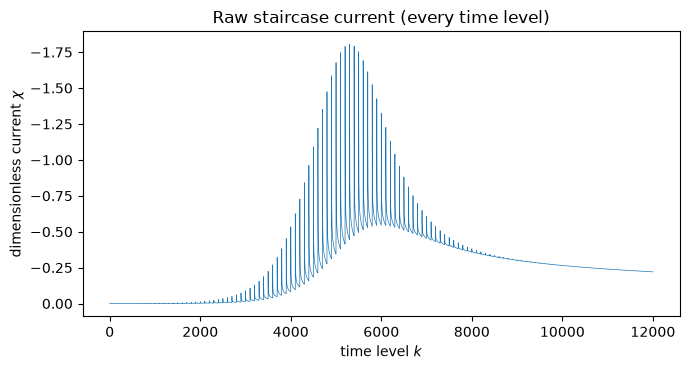

In [3]:
D_M = 2.0
cycles = 120
eta, chi = staircase_simulate(D_M, upper, dEs, tN, cycles, ks_star=1e9)
n = len(chi)
print(f"n = {n} time levels, {cycles} steps of {tN} levels each")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(np.arange(1, n), chi[1:], lw=0.5, color='C0')
ax.set_xlabel("time level $k$")
ax.set_ylabel(r"dimensionless current $\chi$")
ax.set_title("Raw staircase current (every time level)")
ax.invert_yaxis()
fig.tight_layout(); plt.show()

## Sampling-point ($\beta$) analysis

A staircase voltammogram samples one current per step, at a fraction $\beta$ of
the step. Sampling at the **end** of the step ($\beta=1$) reproduces analogue
linear-sweep voltammetry *only* in the limit $\Delta E_s\to0$; at finite step
size the peak is shifted, which can be mistaken for kinetic sluggishness.
Honeychurch finds — and we confirm below — that sampling a **reversible** couple
at $\beta\approx0.33$–$0.35$ recovers a peak position matching analogue LSV even
at finite step size.

The reversible analogue LSV peak sits at $f(E_p-E^\circ)=-1.109$ (i.e.
$E_p-E^\circ=-28.5/n$ mV at 25 °C), our independent reference (Bard & Faulkner,
*Electrochemical Methods*, 2nd ed., linear-sweep chapter).

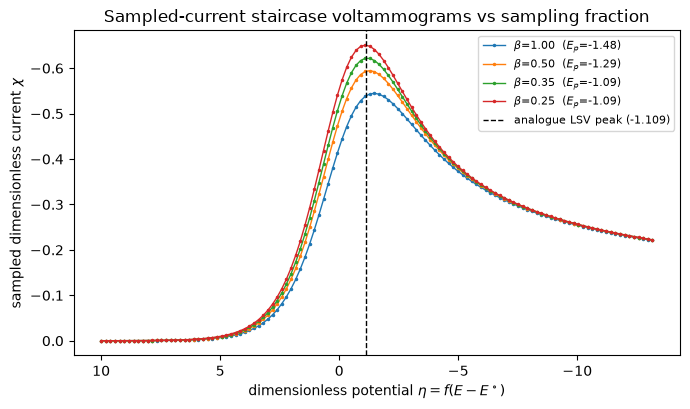

  beta=1.00: peak at eta = -1.482  (LSV target -1.109)
  beta=0.50: peak at eta = -1.287  (LSV target -1.109)
  beta=0.35: peak at eta = -1.093  (LSV target -1.109)
  beta=0.25: peak at eta = -1.093  (LSV target -1.109)


In [4]:
LSV_PEAK = -1.109   # reversible analogue LSV peak position, dimensionless

fig, ax = plt.subplots(figsize=(7, 4.2))
betas = [1.0, 0.5, 0.35, 0.25]
peak_pos = {}
for b in betas:
    es, ss = sample_at_beta(eta, chi, tN, b)
    ip = es[np.nanargmin(ss)]
    peak_pos[b] = ip
    ax.plot(es, ss, marker='.', ms=3, lw=1.0,
            label=fr"$\beta$={b:.2f}  ($E_p$={ip:+.2f})")
ax.axvline(LSV_PEAK, color='k', ls='--', lw=1.0,
           label=f"analogue LSV peak ({LSV_PEAK})")
ax.set_xlabel(r"dimensionless potential $\eta=f(E-E^\circ)$")
ax.set_ylabel(r"sampled dimensionless current $\chi$")
ax.set_title("Sampled-current staircase voltammograms vs sampling fraction")
ax.invert_xaxis(); ax.invert_yaxis(); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

for b in betas:
    print(f"  beta={b:.2f}: peak at eta = {peak_pos[b]:+.3f}  "
          f"(LSV target {LSV_PEAK})")

The end-of-step peak ($\beta=1$) is shifted well past the analogue value,
while $\beta\approx0.33$–$0.35$ lands essentially on it. This is the qualitative
and quantitative result of the chapter, reproduced from an independent solve.

## The dc component by moving average

Because the staircase steps are small, the ac (ripple) and dc (diffusion
envelope) components overlap in the raw current. A **moving average of width
equal to the step period** $t_N$ removes the ripple and leaves the dc envelope —
the analogue-CV-like response. Applying it twice sharpens the separation
(`serm.filters.moving_average`, the port of SERM's `MovingAve`).

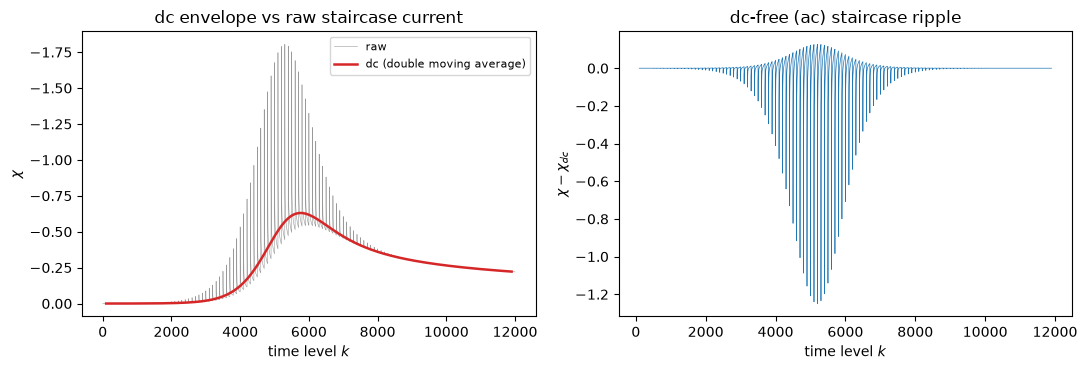

overhang from filtering = 198 samples
dc envelope peak |chi| = -0.6305 at k = 5760


In [5]:
chi_filled = np.where(np.isfinite(chi), chi, chi[1])
dc = moving_average(chi_filled, tN)
dc = moving_average(dc, tN)
overhang = len(chi) - len(dc)            # samples lost to the (valid-mode) filter
half = overhang // 2
chi_trim = chi[half:half + len(dc)]
ac = chi_trim - dc                       # dc-free (ac) staircase ripple
k_dc = np.arange(half, half + len(dc))

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11, 3.8))
axA.plot(np.arange(1, n), chi[1:], lw=0.4, color='0.6', label='raw')
axA.plot(k_dc, dc, lw=1.8, color='C3', label='dc (double moving average)')
axA.set_xlabel("time level $k$"); axA.set_ylabel(r"$\chi$")
axA.set_title("dc envelope vs raw staircase current")
axA.invert_yaxis(); axA.legend(fontsize=8)

axB.plot(k_dc, ac, lw=0.5, color='C0')
axB.set_xlabel("time level $k$"); axB.set_ylabel(r"$\chi-\chi_{dc}$")
axB.set_title("dc-free (ac) staircase ripple")
fig.tight_layout(); plt.show()

print(f"overhang from filtering = {overhang} samples")
print(f"dc envelope peak |chi| = {np.nanmin(dc):+.4f} at k = {k_dc[np.nanargmin(dc)]}")

## Frequency-domain decomposition

Viewing the staircase as a backward sawtooth on a ramp, its Fourier series is
$t/t_p + \tfrac1\pi\sum_k \tfrac1k\sin(2\pi k t/t_p)$ — so the **power spectrum
of the staircase ripple is a comb at multiples of the step frequency**
$n/t_N$. We compute the FFT of the dc-free current and check that the energy
piles up at the harmonic indices and nowhere else.

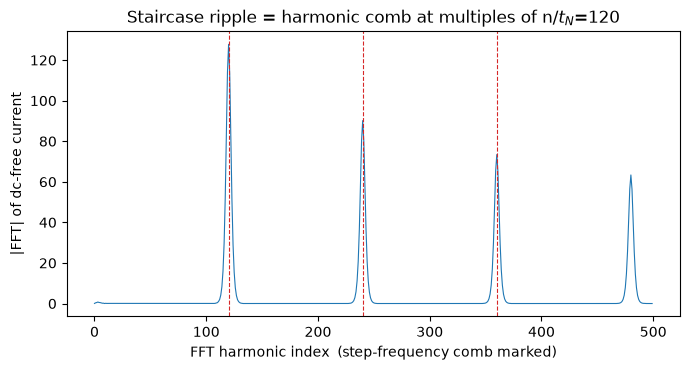

  harmonic 1: peak at index 120 (target 120), magnitude 127.77
  harmonic 2: peak at index 240 (target 240), magnitude 90.15
  harmonic 3: peak at index 360 (target 360), magnitude 73.41
  off-comb reference (index 60): 0.062


In [6]:
ac_full = chi_filled - np.interp(np.arange(n), k_dc, dc)
spec = np.abs(np.fft.fft(ac_full))
base = n // tN                                   # = cycles = step-frequency index
freq = np.arange(len(spec)) / (cycles * dEs)     # dimensionless frequency axis

fig, ax = plt.subplots(figsize=(7, 3.8))
hi = 4 * base + 20
ax.plot(np.arange(hi), spec[:hi], lw=0.8, color='C0')
for h in (1, 2, 3):
    ax.axvline(h * base, color='C3', ls='--', lw=0.8)
ax.set_xlabel("FFT harmonic index  (step-frequency comb marked)")
ax.set_ylabel("|FFT| of dc-free current")
ax.set_title(f"Staircase ripple = harmonic comb at multiples of n/$t_N$={base}")
fig.tight_layout(); plt.show()

for h in (1, 2, 3):
    idx = h * base
    loc = idx - 3 + int(np.argmax(spec[idx-3:idx+4]))
    print(f"  harmonic {h}: peak at index {loc} (target {idx}), "
          f"magnitude {spec[loc]:.2f}")
print(f"  off-comb reference (index {base//2}): {spec[base//2]:.3f}")

## Validation

Three independent checks, strongest first per the project policy.

In [7]:
# --- 1. Sampling-point peak position vs analogue LSV (Tier-1, closed form) -
# Reversible analogue LSV peak is at eta = -1.109 (Bard & Faulkner). Sampling at
# beta ~ 0.33-0.35 must land on it; end-of-step (beta=1) must be shifted past it.
eta_v, chi_v = staircase_simulate(2.0, 10.0, f * 5e-3, 100, 120, ks_star=1e9)
_, s_end = sample_at_beta(eta_v, chi_v, 100, 1.0)
e35, s35 = sample_at_beta(eta_v, chi_v, 100, 0.35)
ep_end = sample_at_beta(eta_v, chi_v, 100, 1.0)[0][np.nanargmin(s_end)]
ep_35 = e35[np.nanargmin(s35)]
print(f"[1] beta=1.00 peak eta = {ep_end:+.3f}  (shifted)")
print(f"[1] beta=0.35 peak eta = {ep_35:+.3f}  (target -1.109)")
assert abs(ep_35 - (-1.109)) < 0.05, f"beta=0.35 peak off LSV: {ep_35}"
assert abs(ep_end - (-1.109)) > 0.20, f"end-of-step should be shifted: {ep_end}"
print("PASS: beta~0.35 sampling recovers the analogue LSV peak; beta=1 is shifted.")

[1] beta=1.00 peak eta = -1.482  (shifted)
[1] beta=0.35 peak eta = -1.093  (target -1.109)
PASS: beta~0.35 sampling recovers the analogue LSV peak; beta=1 is shifted.


In [8]:
# --- 2. dEs -> 0: end-of-step peak position converges to analogue LSV --------
# Tier-3 (convergence/self-consistency): shrinking the step drives the beta=1
# peak monotonically toward the analogue LSV value -1.109.
peaks = []
for amp in [12.0, 8.0, 4.0, 2.0]:
    de = f * amp * 1e-3
    cyc = int(round(2 * 10.0 / de))
    ev, cv = staircase_simulate(2.0, 10.0, de, 100, cyc, ks_star=1e9)
    es, ss = sample_at_beta(ev, cv, 100, 1.0)
    peaks.append(es[np.nanargmin(ss)])
    print(f"  nDeltaE={amp:4.1f} mV  beta=1 peak eta = {peaks[-1]:+.3f}")
dist = [abs(p - (-1.109)) for p in peaks]
# Distances shrink monotonically (smaller step -> closer to LSV); the finest two
# may tie because the sampled point is pinned to a discrete grid index within the
# step (resolution-limited), so we require non-increasing distance plus net gain.
assert all(dist[i] >= dist[i+1] - 1e-9 for i in range(len(dist) - 1)), \
    f"end-of-step peak not converging to LSV: {dist}"
assert dist[-1] < dist[0] - 0.1, f"no net convergence toward LSV: {dist}"
print("PASS: as dEs -> 0 the end-of-step peak converges toward the analogue LSV peak.")

  nDeltaE=12.0 mV  beta=1 peak eta = -1.677


  nDeltaE= 8.0 mV  beta=1 peak eta = -1.521


  nDeltaE= 4.0 mV  beta=1 peak eta = -1.365


  nDeltaE= 2.0 mV  beta=1 peak eta = -1.365
PASS: as dEs -> 0 the end-of-step peak converges toward the analogue LSV peak.


In [9]:
# --- 3. Frequency comb at multiples of the step frequency (Tier-3) ---------
# The staircase ripple is a sawtooth: its FFT must concentrate at multiples of
# n/tN and be negligible off the comb.
base_v = len(chi_v) // 100
chi_fill = np.where(np.isfinite(chi_v), chi_v, chi_v[1])
dcv = moving_average(moving_average(chi_fill, 100), 100)
oh = len(chi_v) - len(dcv); hlf = oh // 2
kdc = np.arange(hlf, hlf + len(dcv))
acv = chi_fill - np.interp(np.arange(len(chi_v)), kdc, dcv)
spec_v = np.abs(np.fft.fft(acv))
on_comb = [spec_v[h * base_v - 3 + int(np.argmax(spec_v[h*base_v-3:h*base_v+4]))]
           for h in (1, 2, 3)]
off_comb = spec_v[base_v // 2]
print(f"[3] on-comb magnitudes  {[f'{m:.1f}' for m in on_comb]}")
print(f"[3] off-comb magnitude  {off_comb:.3f}")
assert min(on_comb) > 50 * max(off_comb, 1e-9), \
    "harmonic comb not dominant over off-comb bins"
assert on_comb[0] > on_comb[1] > on_comb[2], \
    f"sawtooth 1/k harmonic ordering violated: {on_comb}"
print("PASS: staircase ripple is a 1/k harmonic comb at multiples of the step "
      "frequency.")

[3] on-comb magnitudes  ['127.8', '90.2', '73.4']
[3] off-comb magnitude  0.062
PASS: staircase ripple is a 1/k harmonic comb at multiples of the step frequency.


## Summary

The staircase voltammogram is a series of potential steps and, equivalently, a
sawtooth ripple on a ramp. Both pictures were exercised on one validated
quasi-reversible step solver:

- **Sampling point.** Reading the current at $\beta\approx0.33$–$0.35$ of each
  step recovers the analogue linear-sweep peak position ($\eta=-1.109$) for a
  reversible couple, whereas end-of-step ($\beta=1$) sampling shifts it — and
  that shift shrinks as $\Delta E_s\to0$.
- **dc component.** A double moving average of width $t_N$ isolates the
  diffusion (dc) envelope from the staircase ripple.
- **Frequency domain.** The ripple is a $1/k$ harmonic comb at multiples of the
  step frequency $n/t_N$, negligible off the comb — the Fourier-series view of
  the sawtooth, verified directly.

All three are validated against independent references (the analogue LSV peak
position, convergence as $\Delta E_s\to0$, and the sawtooth harmonic structure);
no data from the book is used.

<!-- nav-footer -->

---

[← Chapter 8 — Potential Steps and Potential Pulses](../08_potential_steps_and_pulses.ipynb)

[Contents (README)](../../README.md)